# Lab - 52087 Neural Fields

This lab explores **neural fields** (implicit neural representations) for 2D image reconstruction. We treat an image as a continuous function:
- input: pixel coordinates (x,y) (normalized to [-1,1])
- output: RGB color in [0,1]

The lab is organized into three stages.

1) Baseline MLP  
Train a standard MLP that maps 2D coordinates to RGB. You should observe the classic *low-frequency bias* (blurry reconstructions).

2) Positional Encoding (PE)  
Encode coordinates with higher-frequency features before feeding them to an MLP. We include two options commonly used in neural fields see 6.1 in [paper](https://arxiv.org/pdf/2006.10739):
- sinusoidal Fourier features (deterministic frequency bands) 
- Gaussian random Fourier features (random frequencies sampled from a Gaussian)

3) SIREN  
Replace ReLU with sine activations and use SIREN-style initialization (periodic activation as an inductive bias) to represent higher frequencies without explicit input encoding.

During training we track basic metrics (loss, PSNR; optional SSIM) and plot training dynamics. In the student version, you can remove the plotting/metrics blocks and ask students to implement them.


In [1]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda



## Data Preparation

To train a neural field on an image, we need a dataset of coordinate–color pairs. Each pixel location is treated as a coordinate \((x,y)\) in a continuous domain (normalized to \([-1,1]\)), and the corresponding RGB value is the target. We provide utility functions to load an image from disk or generate a synthetic pattern and then sample a dense grid of coordinates and colors.

If you want to train on your own image, place the image file in the same directory as this notebook and set `image_path` accordingly. The default synthetic pattern demonstrates the method without requiring external files.


In [3]:

from typing import Tuple

def load_image(path: str, resize: Tuple[int, int]=(128, 128)) -> np.ndarray:
    # Load an image from path, resize to the desired resolution and return a normalized
    # numpy array of shape (H, W, 3) with values in [0,1].
    img = Image.open(path).convert('RGB')
    img = img.resize(resize)
    img_np = np.asarray(img, dtype=np.float32) / 255.0
    return img_np


def generate_synthetic_image(resolution: int = 128) -> np.ndarray:
    # Generate a synthetic RGB image using sinusoidal patterns.  This avoids external
    # dependencies and provides a known ground truth with high‑frequency content.
    x = np.linspace(0, 1, resolution)
    y = np.linspace(0, 1, resolution)
    xv, yv = np.meshgrid(x, y)
    img = np.zeros((resolution, resolution, 3), dtype=np.float32)
    # Red channel: high‑frequency checkerboard pattern
    img[..., 0] = (np.sin(2 * np.pi * 6 * xv) * np.sin(2 * np.pi * 6 * yv) + 1) / 2
    # Green channel: low‑frequency radial gradient
    r = np.sqrt((xv - 0.5) ** 2 + (yv - 0.5) ** 2)
    img[..., 1] = 1 - r / np.max(r)
    # Blue channel: diagonal stripes
    img[..., 2] = (np.sin(2 * np.pi * 4 * (xv + yv)) + 1) / 2
    return img


def prepare_dataset(img: np.ndarray) -> Tuple[torch.Tensor, torch.Tensor]:
    # Given an image array of shape (H, W, 3), return tensors:
    #  coords: (N, 2) containing (x,y) in [-1,1]
    #  colors: (N, 3) containing RGB in [0,1]
    h, w, c = img.shape
    ys = np.linspace(-1.0, 1.0, h)
    xs = np.linspace(-1.0, 1.0, w)
    xv, yv = np.meshgrid(xs, ys)
    coords = np.stack([xv, yv], axis=-1).reshape(-1, 2).astype(np.float32)
    colors = img.reshape(-1, c).astype(np.float32)
    coords = torch.from_numpy(coords).to(device)
    colors = torch.from_numpy(colors).to(device)
    return coords, colors

###########################################################
### TODO: choose your own image or generate synthetic image
###########################################################

image_path = "wp.jpg"  # e.g., 'your_image.png' or None for synthetic
resolution = 128 

if image_path is not None:
    img_np = load_image(image_path, resize=(resolution, resolution))
else:
    img_np = generate_synthetic_image(resolution)

coords, colors = prepare_dataset(img_np)
print(f"Dataset: {coords.shape[0]} samples, coordinate tensor shape {coords.shape}, color tensor shape {colors.shape}")


Dataset: 16384 samples, coordinate tensor shape torch.Size([16384, 2]), color tensor shape torch.Size([16384, 3])


## Metrics and training dynamics

We report:
- Loss (MSE / L1 / Huber)
- PSNR (higher is better)
- Optional SSIM (if `scikit-image` is installed)

We also plot training curves (loss and PSNR vs. iteration). In the student version, you can remove the plotting functions and ask students to implement them.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim


def mse(pred: torch.Tensor, target: torch.Tensor) -> float:
    return float(torch.mean((pred - target) ** 2).item())


def psnr(pred: torch.Tensor, target: torch.Tensor, data_range: float = 1.0) -> float:
    error = torch.mean((pred - target) ** 2)
    if error <= 0:
        return float("inf")
    return float(20 * torch.log10(torch.tensor(data_range)) - 10 * torch.log10(error))


def try_ssim(pred_img: np.ndarray, gt_img: np.ndarray) -> float | None:
    s, _ = ssim(gt_img, pred_img, channel_axis=-1, data_range=gt_img.max() - gt_img.min(), full=True)
    return float(s)


###########################################################
# start remove
# write necessary helper functions here
# e.g.: plot training curves, show reconstructions, etc.
# end remove
###########################################################


## Stage 1 – Baseline MLP

A simple multilayer perceptron can approximate the mapping \(f_	heta : \mathbb{R}^2 	o \mathbb{R}^3\) from normalized pixel coordinates to RGB values. However, standard activations like ReLU or tanh exhibit a **low‑frequency inductive bias**—they learn smooth, low‑frequency components of the target signal first, causing reconstructions to be blurry and missing fine detail. We build a configurable MLP and a training loop that supports multiple loss functions so you can experiment with different objectives.


In [12]:
from tqdm import tqdm
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, num_layers: int = 4, activation=F.relu):
        super().__init__()
        self.activation = activation
        layers = []
        dim = in_dim
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(dim, hidden_dim))
            dim = hidden_dim
        layers.append(nn.Linear(dim, out_dim))
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return torch.sigmoid(self.layers[-1](x))  # sigmoid bounds outputs in [0,1]


def train_model(model: nn.Module,
                coords: torch.Tensor,
                colors: torch.Tensor,
                num_iters: int = 500,
                lr: float = 1e-3,
                loss_type: str = "mse",
                log_every: int = 200) -> tuple[nn.Module, dict]:

    if loss_type == "mse":
        criterion = nn.MSELoss()
    elif loss_type == "l1":
        criterion = nn.L1Loss()
    elif loss_type == "huber":
        criterion = nn.SmoothL1Loss()
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    coords_batch = coords.to(device)
    colors_batch = colors.to(device)

    history = {"step": [], "loss": [], "psnr": []}

    for it in tqdm(range(1, num_iters + 1)):
        optimizer.zero_grad()
        pred = model(coords_batch)
        loss = criterion(pred, colors_batch)
        loss.backward()
        optimizer.step()

        if it % log_every == 0 or it == 1 or it == num_iters:
            with torch.no_grad():
                cur_mse = torch.mean((pred - colors_batch) ** 2)
                if cur_mse <= 0:
                    cur_psnr = float("inf")
                else:
                    cur_psnr = float(20 * torch.log10(torch.tensor(1.0)) - 10 * torch.log10(cur_mse))
            history["step"].append(it)
            history["loss"].append(float(loss.item()))
            history["psnr"].append(float(cur_psnr))

    return model, history


100%|██████████| 2000/2000 [01:15<00:00, 26.49it/s]


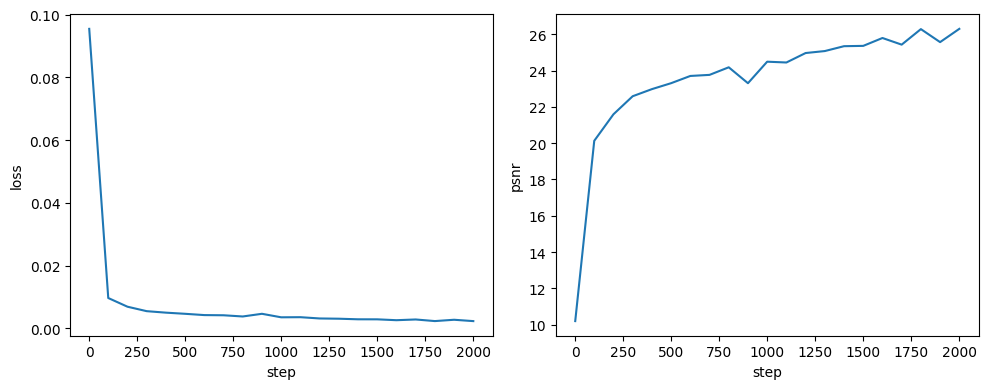

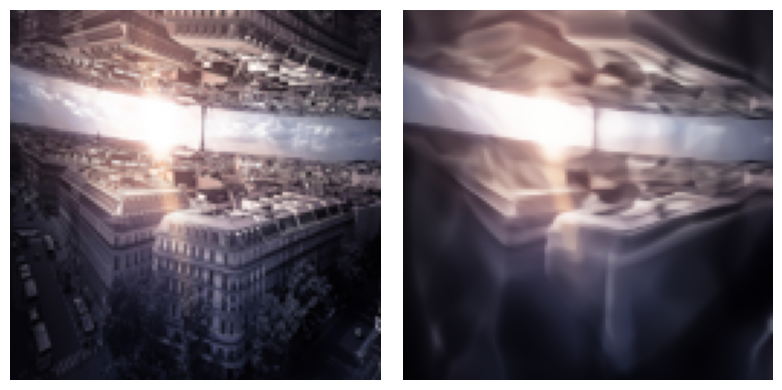

MSE: 0.0023615090176463127
PSNR: 26.268102645874023
SSIM: 0.7459837794303894


In [ ]:
model = MLP(in_dim=2, hidden_dim=512, out_dim=3, num_layers=8)
model, history = train_model(model, coords, colors, num_iters=2000, lr=1e-3, loss_type="mse", log_every=100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["step"], history["loss"])
plt.xlabel("step")
plt.ylabel("loss")
plt.subplot(1, 2, 2)
plt.plot(history["step"], history["psnr"])
plt.xlabel("step")
plt.ylabel("psnr")
plt.tight_layout()
plt.show()

with torch.no_grad():
    pred = model(coords.to(device)).cpu().view(img_np.shape[0], img_np.shape[1], 3).numpy()

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(pred)
plt.axis("off")
plt.tight_layout()
plt.show()

mrc_mse = mse(torch.from_numpy(pred).to(device), torch.from_numpy(img_np).to(device))
mrc_psnr = psnr(torch.from_numpy(pred).to(device), torch.from_numpy(img_np).to(device))
mrc_ssim = try_ssim(pred, img_np)
print("MSE:", mrc_mse)
print("PSNR:", mrc_psnr)
print("SSIM:", mrc_ssim)

## Stage 2 – Positional Encoding

Positional encoding addresses the low-frequency bias by mapping coordinates into a higher-dimensional space that contains sinusoidal components. Two common variants are:

- Sinusoidal PE: deterministic frequencies with increasing scales. For each coordinate dimension and each frequency band (2^i), append sin(2^i\pi x) and cos(2^i\pi x).
- (Optional) Gaussian random Fourier features: sample a frequency matrix B from a Gaussian distribution and compute sin(2\pi Bx) and cos(2\pi Bx). The bandwidth (sigma) controls the frequency spread.

Read more from section 6.1 in [paper](https://arxiv.org/pdf/2006.10739).


In [14]:

class PositionalEncoding:
    # Utility class for positional encodings
    def __init__(self, pe_type: str = 'sin', num_freqs: int = 10, sigma: float = 10.0, input_dim: int = 2):
        self.pe_type = pe_type
        self.num_freqs = num_freqs
        self.sigma = sigma
        self.input_dim = input_dim
        if pe_type == 'sin':
            self.out_dim = input_dim * num_freqs * 2
            self.B = None
        elif pe_type == 'gaussian':
            self.out_dim = num_freqs * 2
            self.B = torch.randn(num_freqs, input_dim) * sigma
        else:
            raise ValueError(f"Unknown pe_type: {pe_type}")


    def encode(self, coords: torch.Tensor) -> torch.Tensor:
        if self.pe_type == 'sin':
            outs = []
            for i in range(self.num_freqs):
                freq = 2.0 ** i
                outs.append(torch.sin(freq * np.pi * coords))
                outs.append(torch.cos(freq * np.pi * coords))
            return torch.cat(outs, dim=-1)
        elif self.pe_type == 'gaussian':
            B = self.B.to(coords.device)
            proj = 2 * np.pi * coords @ B.T
            return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        else:
            raise ValueError(f"Unknown pe_type: {self.pe_type}")


def build_pe_mlp(pe: PositionalEncoding, hidden_dim: int = 128, num_layers: int = 4) -> nn.Module:
    return MLP(in_dim=pe.out_dim, hidden_dim=hidden_dim, out_dim=3, num_layers=num_layers)

100%|██████████| 2000/2000 [00:02<00:00, 857.46it/s]


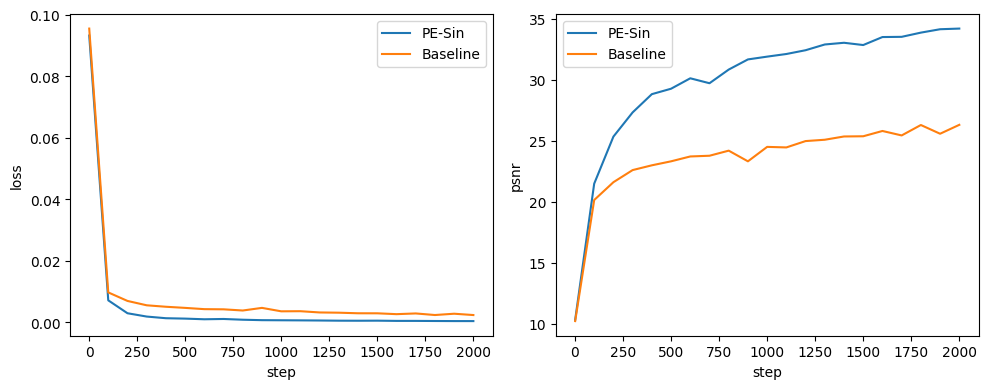

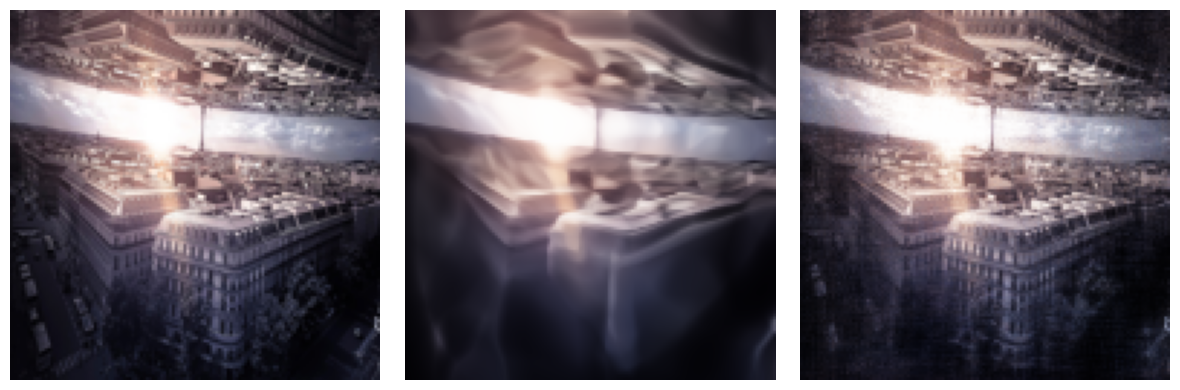

PE-Sin MSE: 0.0003754999488592148
PE-Sin PSNR: 34.253902435302734
PE-Sin SSIM: 0.9263870716094971


100%|██████████| 2000/2000 [00:02<00:00, 846.10it/s]


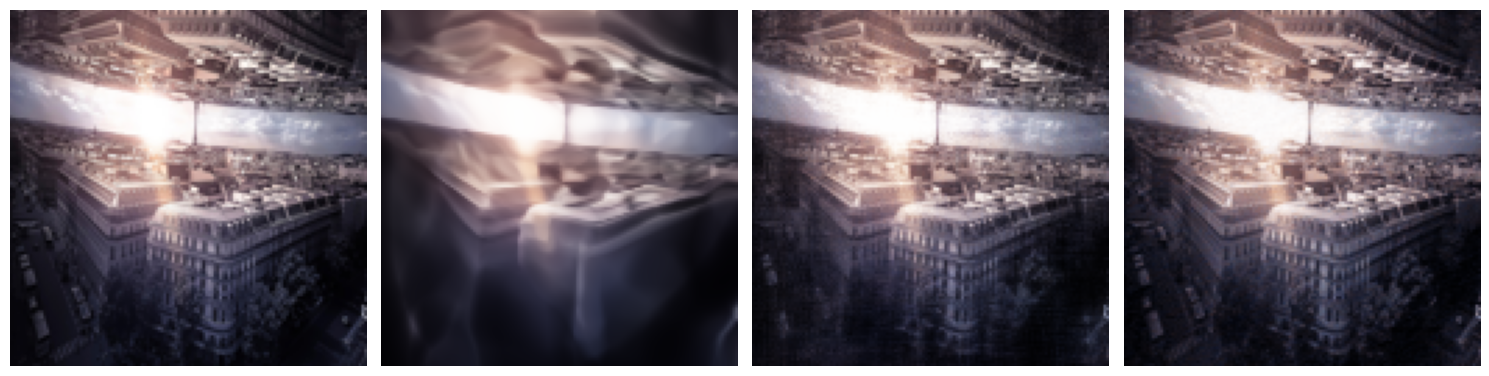

In [ ]:
num_freqs_sin = 32
num_features_gaussian = 64
hidden_dim = 128


pe_sin = PositionalEncoding(pe_type='sin', num_freqs=num_freqs_sin, input_dim=2)
model_pe_sin = build_pe_mlp(pe_sin, hidden_dim=hidden_dim, num_layers=4)
coords_encoded_sin = pe_sin.encode(coords)
model_pe_sin, history_pe_sin = train_model(model_pe_sin, coords_encoded_sin, colors, num_iters=2000, lr=1e-3, loss_type="mse", log_every=100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_pe_sin["step"], history_pe_sin["loss"], label="PE-Sin")
plt.plot(history["step"], history["loss"], label="Baseline")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_pe_sin["step"], history_pe_sin["psnr"], label="PE-Sin")
plt.plot(history["step"], history["psnr"], label="Baseline")
plt.xlabel("step")
plt.ylabel("psnr")
plt.legend()
plt.tight_layout()
plt.show()

with torch.no_grad():
    pred_pe_sin = model_pe_sin(coords_encoded_sin.to(device)).cpu().view(img_np.shape[0], img_np.shape[1], 3).numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(pred)
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(pred_pe_sin)
plt.axis("off")
plt.tight_layout()
plt.show()

mrc_mse_pe = mse(torch.from_numpy(pred_pe_sin).to(device), torch.from_numpy(img_np).to(device))
mrc_psnr_pe = psnr(torch.from_numpy(pred_pe_sin).to(device), torch.from_numpy(img_np).to(device))
mrc_ssim_pe = try_ssim(pred_pe_sin, img_np)
print("PE-Sin MSE:", mrc_mse_pe)
print("PE-Sin PSNR:", mrc_psnr_pe)
print("PE-Sin SSIM:", mrc_ssim_pe)

pe_gaussian = PositionalEncoding(pe_type='gaussian', num_freqs=num_features_gaussian, sigma=10.0, input_dim=2)
model_pe_gaussian = build_pe_mlp(pe_gaussian, hidden_dim=hidden_dim, num_layers=4)
coords_encoded_gaussian = pe_gaussian.encode(coords)
model_pe_gaussian, history_pe_gaussian = train_model(model_pe_gaussian, coords_encoded_gaussian, colors, num_iters=2000, lr=1e-3, loss_type="mse", log_every=100)

with torch.no_grad():
    pred_pe_gaussian = model_pe_gaussian(coords_encoded_gaussian.to(device)).cpu().view(img_np.shape[0], img_np.shape[1], 3).numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(pred)
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(pred_pe_sin)
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(pred_pe_gaussian)
plt.axis("off")
plt.tight_layout()
plt.show()

## Stage 3 – SIREN (Sinusoidal Representation Network)

Instead of injecting high-frequency information through the inputs (PE), SIREN modifies the network’s activations. Each hidden layer uses a sine nonlinearity $\sin(\omega_0 Wx + b)$ with a frequency scale $\omega_0$ and a specialized weight initialization. This enables representation of fine details and well-behaved derivatives.

See more in the [SIREN paper](https://arxiv.org/pdf/2006.09661).

Below we implement a basic SIREN and compare it to the PE-based models.


In [16]:

class SineLayer(nn.Module):
    # A single fully connected layer with sine activation and specialized initialization
    def __init__(self, in_features: int, out_features: int, bias: bool = True,
                 is_first: bool = False, omega_0: float = 30.0):
        super().__init__()
        self.in_features = in_features
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # First layer initialization: weights ~ U(-1/in_features, 1/in_features)
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                # Subsequent layers: weights ~ U(-sqrt(6/in_features)/omega_0, sqrt(6/in_features)/omega_0)
                bound = np.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)
            if self.linear.bias is not None:
                self.linear.bias.uniform_(-np.pi, np.pi)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.omega_0 * self.linear(input))

class SIREN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, num_layers: int = 5, omega_0: float = 30.0):
        super().__init__()
        layers = []
        for i in range(num_layers - 1):
            is_first = (i == 0)
            layers.append(SineLayer(in_features=in_dim if i == 0 else hidden_dim,
                                   out_features=hidden_dim,
                                   is_first=is_first,
                                   omega_0=omega_0))
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.layers = nn.ModuleList(layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers[:-1]:
            x = layer(x)
        return torch.sigmoid(self.layers[-1](x))

# Train a SIREN on raw coordinates (no positional encoding needed)
hidden_dim_siren = 256
num_layers_siren = 5
omega_0 = 30.0


100%|██████████| 2000/2000 [00:11<00:00, 170.77it/s]


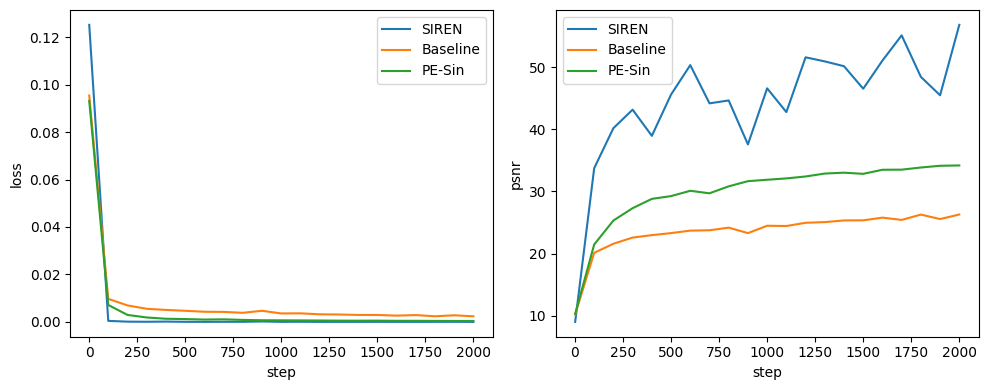

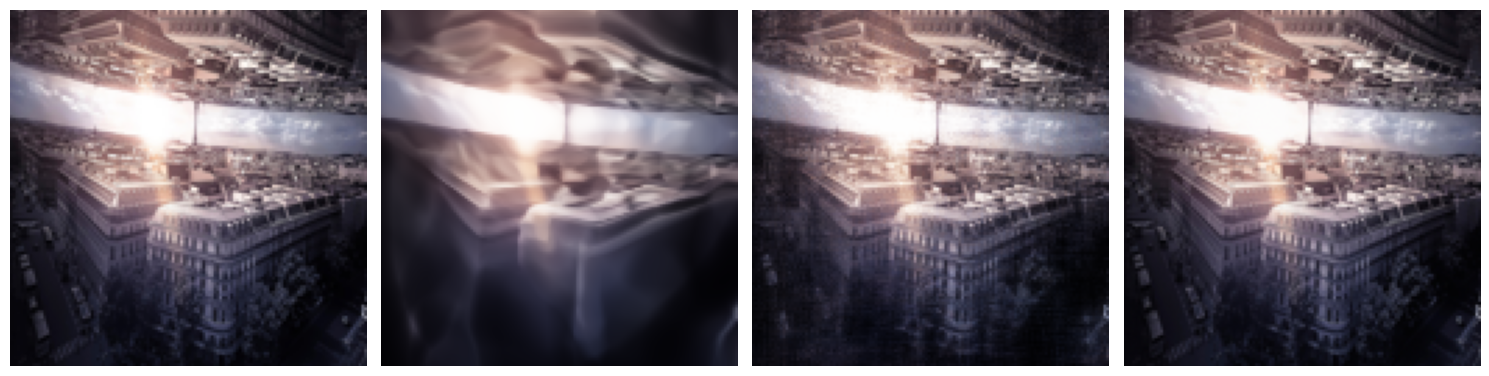

SIREN MSE: 2.074318672384834e-06
SIREN PSNR: 56.83124542236328
SIREN SSIM: 0.9996252059936523


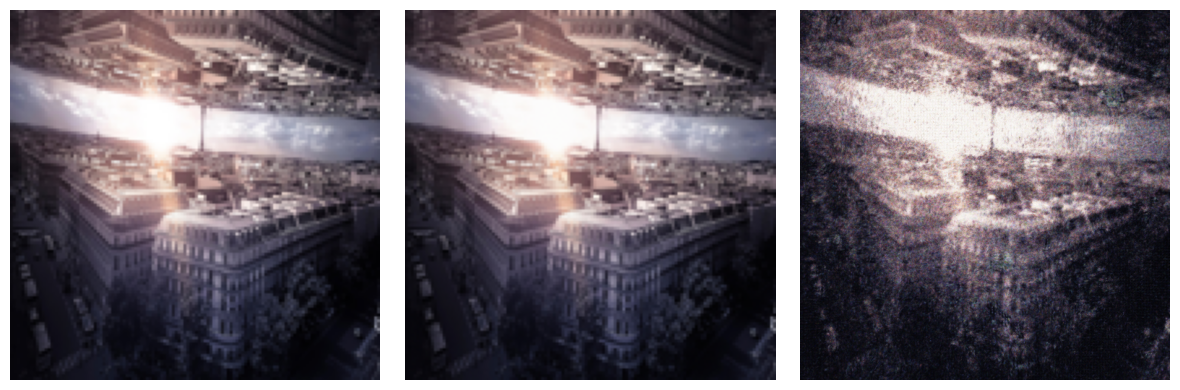

In [ ]:
model_siren = SIREN(in_dim=2, hidden_dim=hidden_dim_siren, out_dim=3, num_layers=num_layers_siren, omega_0=omega_0)
model_siren, history_siren = train_model(model_siren, coords, colors, num_iters=2000, lr=1e-3, loss_type="mse", log_every=100)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_siren["step"], history_siren["loss"], label="SIREN")
plt.plot(history["step"], history["loss"], label="Baseline")
plt.plot(history_pe_sin["step"], history_pe_sin["loss"], label="PE-Sin")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_siren["step"], history_siren["psnr"], label="SIREN")
plt.plot(history["step"], history["psnr"], label="Baseline")
plt.plot(history_pe_sin["step"], history_pe_sin["psnr"], label="PE-Sin")
plt.xlabel("step")
plt.ylabel("psnr")
plt.legend()
plt.tight_layout()
plt.show()

with torch.no_grad():
    pred_siren = model_siren(coords.to(device)).cpu().view(img_np.shape[0], img_np.shape[1], 3).numpy()

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(pred)
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(pred_pe_sin)
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(pred_siren)
plt.axis("off")
plt.tight_layout()
plt.show()
mrc_mse_siren = mse(torch.from_numpy(pred_siren).to(device), torch.from_numpy(img_np).to(device))
mrc_psnr_siren = psnr(torch.from_numpy(pred_siren).to(device), torch.from_numpy(img_np).to(device))
mrc_ssim_siren = try_ssim(pred_siren, img_np)
scale = 4
h_hr, w_hr = img_np.shape[0] * scale, img_np.shape[1] * scale
ys_hr = np.linspace(-1.0, 1.0, h_hr)
xs_hr = np.linspace(-1.0, 1.0, w_hr)
xv_hr, yv_hr = np.meshgrid(xs_hr, ys_hr)
coords_hr = np.stack([xv_hr, yv_hr], axis=-1).reshape(-1, 2).astype(np.float32)
coords_hr_tensor = torch.from_numpy(coords_hr).to(device)
with torch.no_grad():
    pred_siren_hr = model_siren(coords_hr_tensor).cpu().view(h_hr, w_hr, 3).numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(pred_siren)
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(pred_siren_hr)
plt.axis("off")
plt.tight_layout()
plt.show()

100%|██████████| 2000/2000 [00:02<00:00, 683.46it/s]


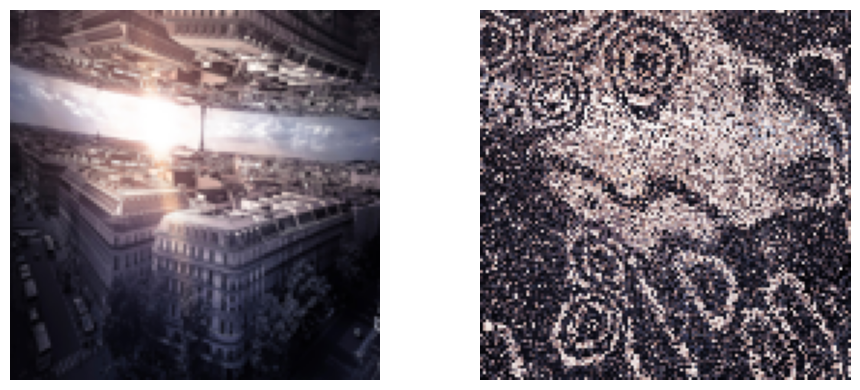

In [ ]:
# [Bonus]

# try to use only partial data to train the SIREN or PE model
# sample only 10% to 30% of data and train the model

sample_ratio = 0.2
n_samples = int(len(coords) * sample_ratio)
indices = torch.randperm(len(coords))[:n_samples]
coords_subset = coords[indices]
colors_subset = colors[indices]

model_siren_sparse = SIREN(in_dim=2, hidden_dim=hidden_dim_siren, out_dim=3, num_layers=num_layers_siren, omega_0=omega_0)
model_siren_sparse, history_siren_sparse = train_model(model_siren_sparse, coords_subset, colors_subset, num_iters=2000, lr=1e-3, loss_type="mse", log_every=100)

with torch.no_grad():
    pred_siren_sparse = model_siren_sparse(coords.to(device)).cpu().view(img_np.shape[0], img_np.shape[1], 3).numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(pred_siren_sparse)
plt.axis("off")
plt.tight_layout()
plt.show()

mrc_mse_sparse = mse(torch.from_numpy(pred_siren_sparse).to(device), torch.from_numpy(img_np).to(device))
mrc_psnr_sparse = psnr(torch.from_numpy(pred_siren_sparse).to(device), torch.from_numpy(img_np).to(device))

# DOESNT WORK YET 